In [1]:
import time
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import cv2
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision
from torchvision import transforms
from torchinfo import summary
import torchvision.models as models
import torch.optim as optim
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image
from itertools import cycle

In [2]:
print("--- System Information ---")
try:
    # Check for GPU and set device
    gpu_info = !nvidia-smi --query-gpu=gpu_name --format=csv
    if len(gpu_info) > 1:
        gpu_name = gpu_info[1]
        print(f"GPU: {gpu_name}")
        device = torch.device('cuda')
    else:
        gpu_name = "No GPU available"
        print(f"GPU: {gpu_name} (Using CPU)")
        device = torch.device('cpu')
except Exception as e:
    gpu_name = "Error checking GPU"
    print(f"GPU: {gpu_name} (Using CPU)")
    device = torch.device('cpu')

# --- Variables ---
seed = 42
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True # For reproducibility on CUDA
    torch.backends.cudnn.benchmark = False
np.random.seed(seed)
random.seed(seed)

## IMPORTANT: Update this path to your dataset location in Kaggle ##
# NOTE: The user provided a path for a Cucumber dataset initially, but the code
# is explicitly set up for the 'Betel Leaf Image Dataset from Bangladesh'.
data_dir = "/kaggle/input/original-image-of-cucumber-disease-recognition/Original Image"
# data_dir = "/kaggle/input/original-image-of-cucumber-disease-recognition" # Use this if changing to cucumber dataset

output_dir = "/kaggle/working/processed-dataset"
checkpoints_path = "/kaggle/working/"
os.makedirs(output_dir, exist_ok=True)

# --- Hyperparameters ---
train_batch = 32
test_batch = 16
total_class = 8
learning_rate = 0.0001
decay = 1e-4 # Weight decay (L2 regularization)
initial_epochs = 20
finetune_epochs = 15
patience = 5
image_size = (224, 224)

print(f"Device: {device}")
print(f"Image Size: {image_size}")
print(f"Total Classes: {total_class}")

--- System Information ---
GPU: No GPU available (Using CPU)
Device: cpu
Image Size: (224, 224)
Total Classes: 8



--- Initial Dataset Info ---
Found 1289 images across 8 classes in /kaggle/input/original-image-of-cucumber-disease-recognition/Original Image.

Class Distribution (Before Split):
label
Pythium Fruit Rot    169
Downy Mildew         160
Bacterial Wilt       160
Fresh Leaf           160
Fresh Cucumber       160
Anthracnose          160
Gummy Stem Blight    160
Belly Rot            160
Name: count, dtype: int64

--- Dataset Split Sizes ---
Train Set: 902 images (70.0%)
Validation Set: 193 images (15.0%)
Test Set: 194 images (15.1%)

--- Starting Data Preprocessing (Resize and Save) ---


Processing train set:   0%|          | 0/902 [00:00<?, ?it/s]

Processing validation set:   0%|          | 0/193 [00:00<?, ?it/s]

Processing test set:   0%|          | 0/194 [00:00<?, ?it/s]


--- Label Encoding ---
Anthracnose -> 0
Bacterial Wilt -> 1
Belly Rot -> 2
Downy Mildew -> 3
Fresh Cucumber -> 4
Fresh Leaf -> 5
Gummy Stem Blight -> 6
Pythium Fruit Rot -> 7
Actual Total Classes based on data: 8

--- Initializing ResNet50 Model ---


...

Epoch 11/15 -> Train Loss: 0.122, Train Acc: 0.966 | Val Loss: 0.139, Val Acc: 0.969
   (No improvement for 3 epochs)


Epoch 12/15 [FT]:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 12/15 -> Train Loss: 0.116, Train Acc: 0.972 | Val Loss: 0.157, Val Acc: 0.948
   (No improvement for 4 epochs)


Epoch 13/15 [FT]:   0%|          | 0/29 [00:00<?, ?it/s]

Epoch 13/15 -> Train Loss: 0.115, Train Acc: 0.965 | Val Loss: 0.140, Val Acc: 0.959
   (No improvement for 5 epochs)
🛑 Early stopping Stage 2 after 5 epochs with no improvement.

--- Training & Fine-Tuning Finished ---
Total Time: 96.27 minutes


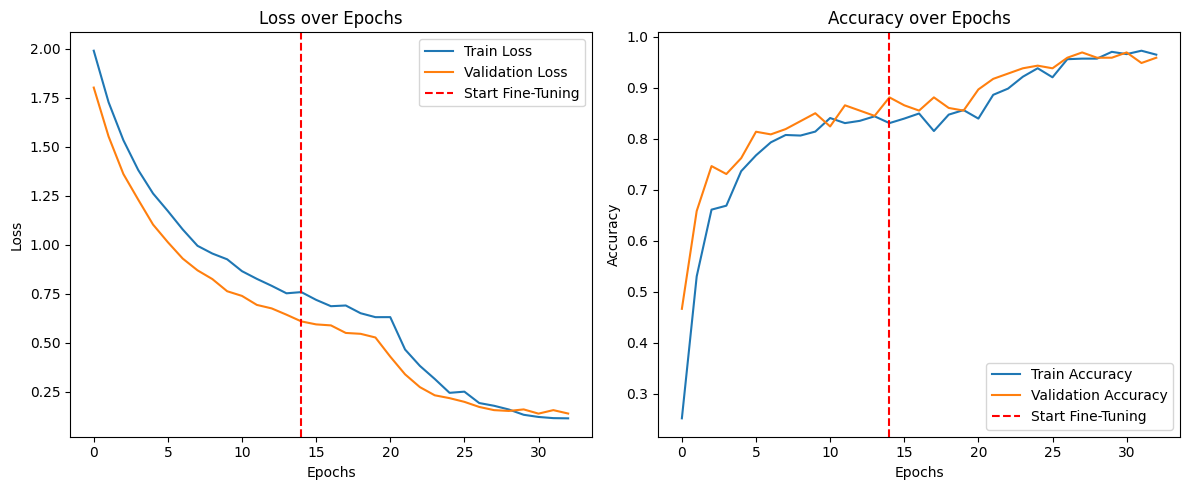


--- Evaluating Model on Test Set ---


Evaluating Test Set:   0%|          | 0/13 [00:00<?, ?it/s]

Overall Test Accuracy: 0.933

Classification Report:
                   precision    recall  f1-score   support

      Anthracnose       0.79      0.92      0.85        24
   Bacterial Wilt       1.00      1.00      1.00        24
        Belly Rot       0.92      1.00      0.96        24
     Downy Mildew       0.95      0.83      0.89        24
   Fresh Cucumber       1.00      0.96      0.98        24
       Fresh Leaf       0.96      1.00      0.98        24
Gummy Stem Blight       0.86      0.79      0.83        24
Pythium Fruit Rot       1.00      0.96      0.98        26

         accuracy                           0.93       194
        macro avg       0.94      0.93      0.93       194
     weighted avg       0.94      0.93      0.93       194



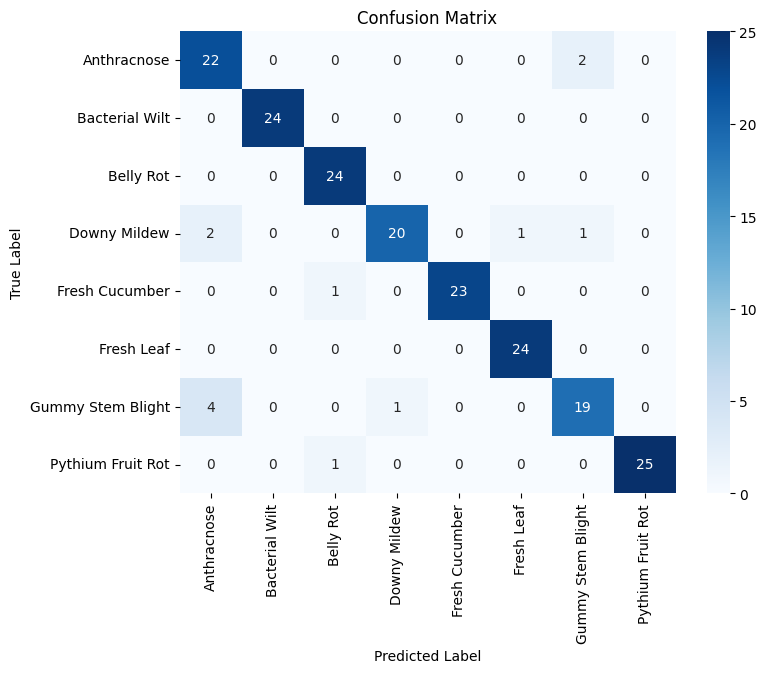

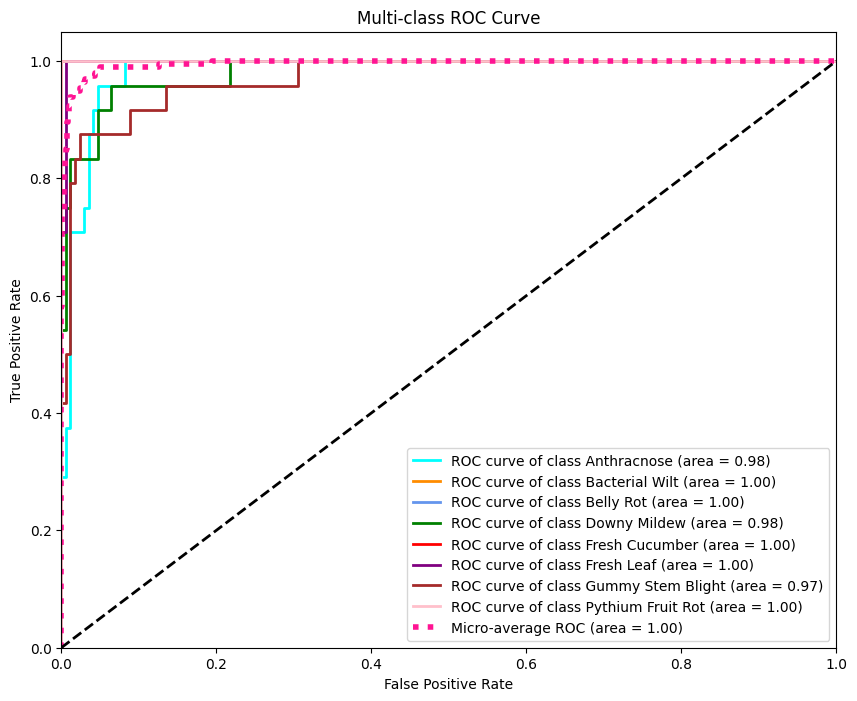


--- Grad-CAM Visualization ---


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


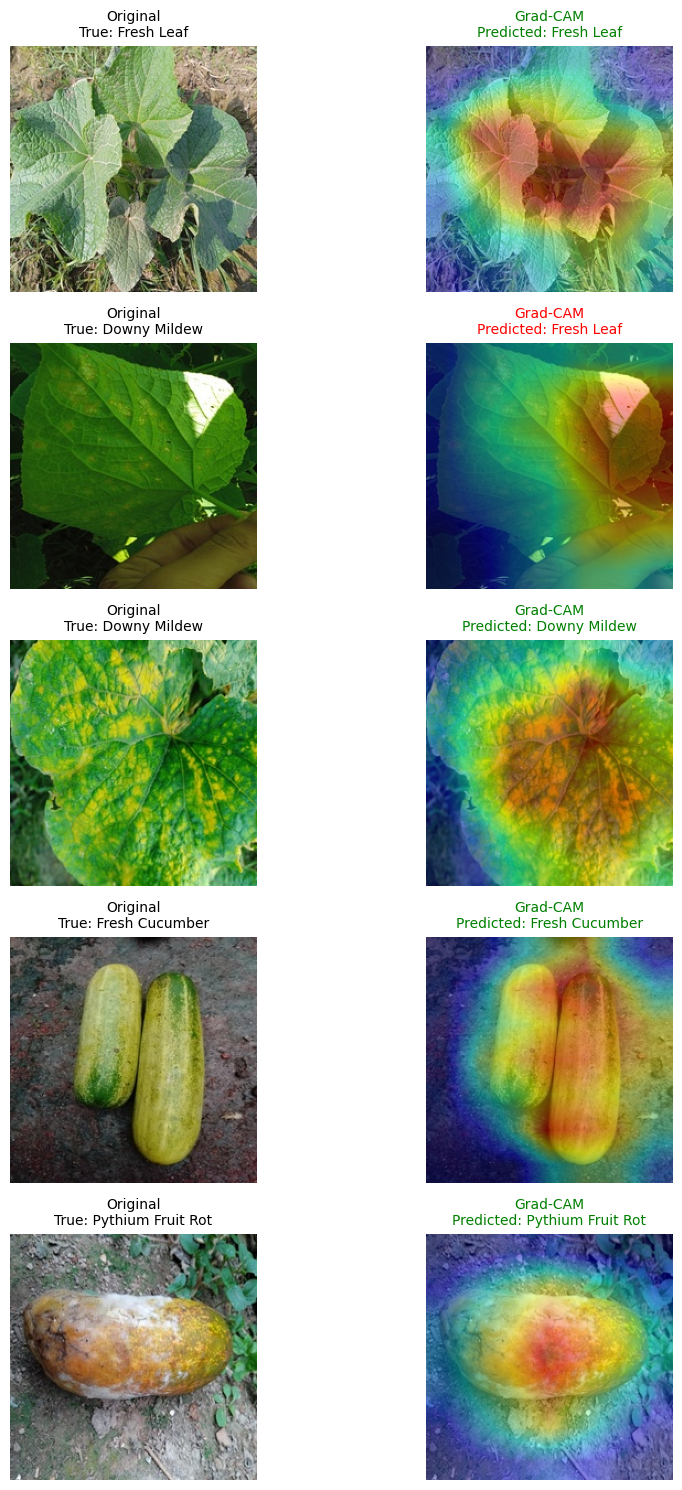

In [3]:
# ==============================================================================
# 3. EXPLORE AND SPLIT THE DATASET
# ==============================================================================
def load_split(split_dir):
    """Recursively loads file paths and labels from the directory structure."""
    file_paths, labels = [], []
    if not os.path.exists(split_dir):
        print(f"Error: Data directory not found at {split_dir}")
        return pd.DataFrame({"file_path": [], "label": []})
        
    for class_name in os.listdir(split_dir):
        class_dir = os.path.join(split_dir, class_name)
        if os.path.isdir(class_dir):
            for image_name in os.listdir(class_dir):
                file_path = os.path.join(class_dir, image_name)
                # Basic check to ensure it's a file and not a hidden one
                if os.path.isfile(file_path) and not image_name.startswith('.'):
                    file_paths.append(file_path)
                    labels.append(class_name)
    print(f"\n--- Initial Dataset Info ---")
    print(f"Found {len(file_paths)} images across {len(set(labels))} classes in {split_dir}.")
    return pd.DataFrame({"file_path": file_paths, "label": labels})

data = load_split(data_dir)

if data.empty:
    raise FileNotFoundError("Could not load any data. Please check the 'data_dir' path.")

print("\nClass Distribution (Before Split):")
print(data['label'].value_counts())

# Split the dataset: Train (70%), Temp (30%)
train_dataframe, temp_dataframe = train_test_split(
    data, test_size=0.30, stratify=data['label'], random_state=seed
)
# Split Temp (30%) into Validation (15%) and Test (15%)
validation_dataframe, test_dataframe = train_test_split(
    temp_dataframe, test_size=0.50, stratify=temp_dataframe['label'], random_state=seed
)

print(f"\n--- Dataset Split Sizes ---")
print(f"Train Set: {len(train_dataframe)} images ({len(train_dataframe)/len(data):.1%})")
print(f"Validation Set: {len(validation_dataframe)} images ({len(validation_dataframe)/len(data):.1%})")
print(f"Test Set: {len(test_dataframe)} images ({len(test_dataframe)/len(data):.1%})")


# ==============================================================================
# 4. DATA PREPROCESSING (Resize and Save)
# ==============================================================================
def data_preprocess(df, split_name, size, quality=95):
    """Resizes and saves images to a new directory structure."""
    split_dir = os.path.join(output_dir, split_name)
    os.makedirs(split_dir, exist_ok=True)
    processed_file_paths = []
    
    # Create a copy to avoid SettingWithCopyWarning on the original slice
    df_copy = df.copy() 
    
    for idx, row in tqdm(df_copy.iterrows(), total=len(df_copy), desc=f"Processing {split_name} set"):
        try:
            label = row['label']
            label_dir = os.path.join(split_dir, label)
            os.makedirs(label_dir, exist_ok=True)
            
            # Open, convert to RGB, resize (using LANCZOS for high quality downsampling)
            img = Image.open(row['file_path']).convert("RGB").resize(size, Image.Resampling.LANCZOS)
            
            file_name = os.path.basename(row['file_path'])
            save_path = os.path.join(label_dir, file_name)
            
            # Save the processed image
            img.save(save_path, optimize=True, quality=quality)
            processed_file_paths.append(save_path)
            
        except Exception as e:
            # Handle potential file errors and skip image
            print(f"Skipping file {row['file_path']} due to error: {e}")
            processed_file_paths.append(None) # Add None as a placeholder for removal
            
    # Filter out failed/skipped images
    df_copy['file_path'] = processed_file_paths
    df_copy.dropna(subset=['file_path'], inplace=True)
    return df_copy

print("\n--- Starting Data Preprocessing (Resize and Save) ---")
train_dataframe = data_preprocess(train_dataframe, "train", size=image_size)
validation_dataframe = data_preprocess(validation_dataframe, "validation", size=image_size)
test_dataframe = data_preprocess(test_dataframe, "test", size=image_size)


# ==============================================================================
# 5. DATASET CLASS, TRANSFORMS, AND DATALOADERS
# ==============================================================================
class ImageDataset(Dataset):
    """Custom PyTorch Dataset class for loading images from a DataFrame."""
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True) # Reset index after dropping rows
        self.transform = transform
        # Create a deterministic label map based on sorted unique labels
        unique_labels = sorted(self.dataframe['label'].unique())
        self.label_map = {label: idx for idx, label in enumerate(unique_labels)}
        # Set total_class based on actual data
        global total_class
        total_class = len(unique_labels)
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, index):
        img_path = self.dataframe.iloc[index]['file_path']
        image = Image.open(img_path).convert("RGB")
        label_name = self.dataframe.iloc[index]['label']
        label = self.label_map[label_name]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

def get_dataloaders(size):
    """Defines transforms and creates DataLoader instances."""
    # Standard normalization values for ImageNet-trained models
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    
    # Training transforms including heavy data augmentation
    train_transform = transforms.Compose([
        transforms.RandomRotation(degrees=15),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomResizedCrop(size, scale=(0.9, 1.0)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(), # Converts PIL Image to Tensor and scales to [0, 1]
        normalize
    ])
    
    # Validation/Test transforms (only resizing, ToTensor, and normalization)
    val_test_transform = transforms.Compose([
        transforms.Resize(size),
        transforms.ToTensor(),
        normalize
    ])
    
    train_dataset = ImageDataset(train_dataframe, transform=train_transform)
    valid_dataset = ImageDataset(validation_dataframe, transform=val_test_transform)
    test_dataset = ImageDataset(test_dataframe, transform=val_test_transform)
    
    # Print label map for reference
    print("\n--- Label Encoding ---")
    for label, idx in train_dataset.label_map.items(): 
        print(f"{label} -> {idx}")
    
    # Create DataLoaders
    train_dataloader = DataLoader(train_dataset, batch_size=train_batch, shuffle=True, num_workers=2, pin_memory=True if device.type == 'cuda' else False)
    validation_dataloader = DataLoader(valid_dataset, batch_size=test_batch, shuffle=False, num_workers=2, pin_memory=True if device.type == 'cuda' else False)
    test_dataloader = DataLoader(test_dataset, batch_size=test_batch, shuffle=False, num_workers=2, pin_memory=True if device.type == 'cuda' else False)
    
    # Update global total_class just in case it was different from the config
    print(f"Actual Total Classes based on data: {total_class}") 
    
    return train_dataloader, validation_dataloader, test_dataloader, train_dataset.label_map

# Run the dataloader setup
train_dataloader, validation_dataloader, test_dataloader, label_map = get_dataloaders(size=image_size)
class_names = list(label_map.keys())


# ==============================================================================
# 6. DEEP LEARNING MODEL (ResNet50)
# ==============================================================================
print("\n--- Initializing ResNet50 Model ---")
# Load pre-trained ResNet50 weights
model = models.resnet50(weights='IMAGENET1K_V1') 

# Get the number of input features for the final fully connected layer
num_ftrs = model.fc.in_features
# Replace the final layer with a new one that has 'total_class' output features
model.fc = nn.Linear(num_ftrs, total_class)
# Move model to the selected device (GPU/CPU)
model = model.to(device)

# Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=decay)
criterion = nn.CrossEntropyLoss()

# Print model summary
summary(model, input_size=(train_batch, 3, 224, 224))


# ==============================================================================
# 7. MODEL TRAINING AND FINE-TUNING
# ==============================================================================
def train_finetune_model(model, criterion, optimizer, train_loader, val_loader, initial_epochs, finetune_epochs, patience, ckpt_path):
    """
    Trains and fine-tunes the model in two stages:
    1. Feature Extraction (Base layers frozen)
    2. Fine-Tuning (All layers unfrozen with a lower learning rate)
    Includes Early Stopping based on validation accuracy.
    """
    train_loss_history, val_loss_history = [], []
    train_acc_history, val_acc_history = [], []
    best_val_acc = 0.0
    no_improvement_count = 0
    total_start_time = time.time()
    
    # --- STAGE 1: Initial Training (Feature Extraction) ---
    print("\n--- Stage 1: Training the Classifier (Frozen Base) ---")
    # Freeze all parameters
    for param in model.parameters(): 
        param.requires_grad = False
    # Unfreeze only the newly added final classifier layer
    for param in model.fc.parameters(): 
        param.requires_grad = True
        
    for epoch in range(initial_epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{initial_epochs} [T]", leave=False)
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            progress_bar.set_postfix(loss=running_loss/total_train, acc=correct_train/total_train)
            
        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train
        train_loss_history.append(epoch_train_loss)
        train_acc_history.append(epoch_train_acc)
        
        # Validation Phase
        model.eval()
        running_val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
        
        epoch_val_loss = running_val_loss / total_val
        epoch_val_acc = correct_val / total_val
        val_loss_history.append(epoch_val_loss)
        val_acc_history.append(epoch_val_acc)
        
        print(f"Epoch {epoch+1}/{initial_epochs} -> Train Loss: {epoch_train_loss:.3f}, Train Acc: {epoch_train_acc:.3f} | Val Loss: {epoch_val_loss:.3f}, Val Acc: {epoch_val_acc:.3f}")
        
        # Checkpoint and Early Stopping Logic
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), os.path.join(ckpt_path, "best_model.pt"))
            print(f"✅ Best model from Stage 1 saved with validation accuracy: {best_val_acc:.3f}")
            no_improvement_count = 0
        else: 
            no_improvement_count += 1
            print(f"   (No improvement for {no_improvement_count} epochs)")
            
        if no_improvement_count >= patience:
            print(f"🛑 Early stopping Stage 1 after {patience} epochs with no improvement.")
            break
            
    # --- STAGE 2: Fine-Tuning ---
    print("\n--- Stage 2: Fine-Tuning (Unfrozen Base) ---")
    # Unfreeze all model parameters for fine-tuning
    for param in model.parameters(): 
        param.requires_grad = True
        
    # Use a much lower learning rate for fine-tuning all layers
    optimizer_ft = optim.Adam(model.parameters(), lr=learning_rate / 10, weight_decay=decay)
    no_improvement_count = 0
    
    # Reload best weights from stage 1 before fine-tuning
    try:
        model.load_state_dict(torch.load(os.path.join(ckpt_path, "best_model.pt")))
        print("Loaded best model weights from Stage 1.")
    except:
        print("Warning: Could not load best model weights from Stage 1.")

    for epoch in range(finetune_epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{finetune_epochs} [FT]", leave=False)
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer_ft.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer_ft.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            progress_bar.set_postfix(loss=running_loss/total_train, acc=correct_train/total_train)
            
        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train
        train_loss_history.append(epoch_train_loss)
        train_acc_history.append(epoch_train_acc)
        
        # Validation Phase
        model.eval()
        running_val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
        
        epoch_val_loss = running_val_loss / total_val
        epoch_val_acc = correct_val / total_val
        val_loss_history.append(epoch_val_loss)
        val_acc_history.append(epoch_val_acc)
        
        print(f"Epoch {epoch+1}/{finetune_epochs} -> Train Loss: {epoch_train_loss:.3f}, Train Acc: {epoch_train_acc:.3f} | Val Loss: {epoch_val_loss:.3f}, Val Acc: {epoch_val_acc:.3f}")
        
        # Checkpoint and Early Stopping Logic
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), os.path.join(ckpt_path, "best_model.pt"))
            print(f"✅ Best model from Stage 2 saved with validation accuracy: {best_val_acc:.3f}")
            no_improvement_count = 0
        else:
            no_improvement_count += 1
            print(f"   (No improvement for {no_improvement_count} epochs)")
            
        if no_improvement_count >= patience:
            print(f"🛑 Early stopping Stage 2 after {patience} epochs with no improvement.")
            break
            
    total_end_time = time.time()
    print(f"\n--- Training & Fine-Tuning Finished ---")
    print(f"Total Time: {(total_end_time - total_start_time)/60:.2f} minutes")
    
    return train_loss_history, train_acc_history, val_loss_history, val_acc_history

# Train and fine-tune the model
train_loss, train_acc, val_loss, val_acc = train_finetune_model(
    model, criterion, optimizer, train_dataloader, validation_dataloader, 
    initial_epochs, finetune_epochs, patience, checkpoints_path
)

# --- Plot Training History ---
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Train Loss'); 
plt.plot(val_loss, label='Validation Loss')
# Use the length of the first stage to determine the start of fine-tuning
start_ft_index = next(i for i, x in enumerate(val_acc) if x == max(val_acc[:initial_epochs])) if max(val_acc[:initial_epochs]) > 0 else initial_epochs 
plt.axvline(x=start_ft_index, color='r', linestyle='--', label='Start Fine-Tuning')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('Loss over Epochs'); plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Train Accuracy'); 
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=start_ft_index, color='r', linestyle='--', label='Start Fine-Tuning')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.title('Accuracy over Epochs'); plt.legend()

plt.tight_layout(); 
plt.show()

# ==============================================================================
# 8. EVALUATION
# ==============================================================================
print("\n--- Evaluating Model on Test Set ---")

# Load the best model weights found during training
best_model_path = os.path.join(checkpoints_path, "best_model.pt")
if os.path.exists(best_model_path):
    model.load_state_dict(torch.load(best_model_path, map_location=device))
else:
    print(f"Warning: Best model checkpoint not found at {best_model_path}. Using final epoch model weights.")


def evaluate_model_full(model, dataloader):
    """Evaluates the model and collects true labels, predictions, and probabilities."""
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating Test Set"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1) # Get probabilities
            _, predicted = torch.max(outputs, 1) # Get predicted class index
            
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())
            
    return np.array(y_true), np.array(y_pred), np.array(y_prob)

# Run evaluation
y_true, y_pred, y_prob = evaluate_model_full(model, test_dataloader)

# --- Performance Metrics ---
print(f"Overall Test Accuracy: {accuracy_score(y_true, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label'); plt.ylabel('True Label'); plt.title('Confusion Matrix'); 
plt.show()


# --- ROC Curve and AUC Score ---
# Binarize the true labels for multi-class ROC calculation
y_true_binarized = label_binarize(y_true, classes=range(total_class))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(total_class):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC (useful for imbalanced datasets)
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_binarized.ravel(), y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown', 'pink'][:total_class])
for i, color in zip(range(total_class), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:0.2f})')

plt.plot(fpr["micro"], tpr["micro"], label=f'Micro-average ROC (area = {roc_auc["micro"]:0.2f})', color='deeppink', linestyle=':', lw=4)
plt.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal line (random chance)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); 
plt.title('Multi-class ROC Curve'); 
plt.legend(loc="lower right"); 
plt.show()



# ==============================================================================
# 9. EXPLAINABLE AI (Grad-CAM)
# ==============================================================================
class GradCAM:
    """Implements Gradient-weighted Class Activation Mapping (Grad-CAM)"""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self._register_hooks()
        
    def _register_hooks(self):
        """Registers forward and backward hooks to capture activations and gradients."""
        def f_hook(module, input, output): 
            self.activations = output.detach()
            
        def b_hook(module, grad_input, grad_output): 
            self.gradients = grad_output[0].detach()
            
        # Register hooks
        self.hook_handles.extend([
            self.target_layer.register_forward_hook(f_hook),
            self.target_layer.register_backward_hook(b_hook)
        ])
        
    def remove_hooks(self):
        """Removes the registered hooks."""
        for handle in self.hook_handles: 
            handle.remove()
            
    def generate_cam(self, input_tensor, target_class=None):
        """Generates the Grad-CAM heatmap for the input tensor."""
        self.model.eval()
        input_tensor.requires_grad_(True)
        
        # Forward pass
        output = self.model(input_tensor)
        
        # Determine the target class for backpropagation
        if target_class is None: 
            target_class = output.argmax(dim=1).item()
            
        # Zero gradients and backpropagate the score of the target class
        self.model.zero_grad()
        class_score = output[:, target_class]
        class_score.backward()
        
        # Global Average Pooling on the gradients (alpha_k)
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        
        # Weighted sum of feature maps
        cam = torch.sum(weights * self.activations, dim=1).squeeze().cpu().numpy()
        
        # Apply ReLU to the CAM
        cam = np.maximum(cam, 0)
        
        # Resize CAM to image size and normalize
        cam = cv2.resize(cam, (224, 224))
        cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)
        
        return cam

def denormalize_image(tensor, mean, std):
    """Denormalizes a tensor for visualization."""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std): 
        t.mul_(s).add_(m)
    return tensor

def show_gradcam(model, dataloader, device, target_layer, classes, num_samples=5):
    """Visualizes Grad-CAM heatmaps for a number of test samples."""
    gradcam = GradCAM(model, target_layer)
    data_iter = iter(dataloader)
    
    plt.figure(figsize=(10, num_samples * 3))
    
    # Define mean and std tensors for denormalization
    mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std_t = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for i in range(num_samples):
        try:
            inputs, labels = next(data_iter)
        except StopIteration:
            print(f"Stopped at {i} samples. End of dataloader reached.")
            break
            
        input_tensor = inputs[0].unsqueeze(0).to(device)
        label = labels[0].item()
        
        # Get model prediction and CAM
        output = model(input_tensor)
        pred_class = output.argmax(dim=1).item()
        cam = gradcam.generate_cam(input_tensor, pred_class)
        
        # Denormalize and prepare original image for display
        img_denorm = denormalize_image(inputs[0].cpu(), mean_t, std_t)
        img_np = np.clip(img_denorm.numpy().transpose(1, 2, 0), 0, 1) # HWC format, clip to [0, 1]
        
        # Convert CAM to heatmap and create overlay
        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        overlay = cv2.addWeighted(cv2.cvtColor(np.uint8(255 * img_np), cv2.COLOR_RGB2BGR), 0.6, heatmap, 0.4, 0)
        
        # Plot Original Image
        plt.subplot(num_samples, 2, 2 * i + 1)
        plt.imshow(img_np)
        plt.title(f"Original\nTrue: {classes[label]}", fontsize=10)
        plt.axis('off')
        
        # Plot Grad-CAM Overlay
        plt.subplot(num_samples, 2, 2 * i + 2)
        plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        plt.title(f"Grad-CAM\nPredicted: {classes[pred_class]}", fontsize=10, color='green' if label == pred_class else 'red')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
    gradcam.remove_hooks() # Clean up hooks


print("\n--- Grad-CAM Visualization ---")
# The target layer for ResNet50 is typically the last convolutional layer before the global average pooling.
# layer4[-1].conv3 is the last convolution in the last bottleneck block.
target_layer = model.layer4[-1].conv3 
show_gradcam(model, test_dataloader, device, target_layer, class_names, num_samples=5)